### Uma instituição financeira realiza campanhas de marketing por telefone para oferecer produtos de investimento aos seus clientes. No entanto, muitos contatos não geram conversão, aumentando o custo operacional da campanha.
### O objetivo do projeto é usar análise multivariada para identificar quais características dos clientes, histórico bancário e variáveis da campanha estão mais associadas à aceitação da oferta, permitindo que a empresa direcione melhor seus contatos e aumente a taxa de conversão.

# *_Quais fatores mais influenciam a decisão de um cliente em aceitar ou recusar uma oferta de depósito a prazo em uma campanha bancária?_*

### Carregando Dados 

In [345]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight






# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
features = bank_marketing.data.features 
target = bank_marketing.data.targets 
  



In [346]:
features.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN


In [347]:
dicit_variaveis = {
    "age": "Idade do cliente",
    "job": "Ocupação do cliente",
    "marital": "Estado civil do cliente",
    "education": "Nível de escolaridade do cliente",
    "default": "Indica se o cliente possui crédito em inadimplência",
    "balance": "Saldo médio anual do cliente em euros",
    "housing": "Indica se o cliente possui empréstimo habitacional",
    "loan": "Indica se o cliente possui empréstimo pessoal",
    "contact": "Tipo de contato utilizado na campanha",
    "day_of_week": "Dia em que ocorreu o último contato",
    "month": "Mês em que ocorreu o último contato",
    "duration": "Duração do último contato em segundos",
    "campaign": "Número de contatos realizados durante esta campanha",
    "pdays": "Número de dias desde o último contato em uma campanha anterior",
    "previous": "Número de contatos realizados antes desta campanha",
    "poutcome": "Resultado da campanha de marketing anterior",
    "y": "Indica se o cliente aceitou ou não a oferta"
}

In [348]:
print("Dados Nulos :", target.isnull().sum() )
target.value_counts()

Dados Nulos : y    0
dtype: int64


y  
no     39922
yes     5289
Name: count, dtype: int64

In [349]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
dtypes: int64(7), object(9)
memory usage: 5.5+ MB


# Limpeza e Processamento de Dados Inicial

In [350]:
print(f"{features['default'].value_counts()}")
print(f"\n{features['housing'].value_counts()}")
print(f"\n{features['loan'].value_counts()}")
print(f"\n{features['poutcome'].value_counts()}")

default
no     44396
yes      815
Name: count, dtype: int64

housing
yes    25130
no     20081
Name: count, dtype: int64

loan
no     37967
yes     7244
Name: count, dtype: int64

poutcome
failure    4901
other      1840
success    1511
Name: count, dtype: int64


Com exceção da variavel poutcome todas as demais são variaveis binarias , que estão totalmente preenchidas

In [351]:
features.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

In [352]:
features['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
Name: count, dtype: int64

In [353]:
features['contact'].value_counts()

contact
cellular     29285
telephone     2906
Name: count, dtype: int64

In [354]:
# Contar quantos valores nulos existem
n_nulos = features['job'].isna().sum()

# Total de linhas do DataFrame
total_linhas = len(features)

# Calcular porcentagem
porcentagem_nulos = (n_nulos / total_linhas) * 100

print(f"Nulos em job: {n_nulos} ({porcentagem_nulos:.2f}%)")

Nulos em job: 288 (0.64%)


A variável job possui poucos valores ausentes, representando menos de 1% da base, por isso será preenchida com a moda. Para contact, os valores ausentes serão preenchidos como "unknown". Para poutcome, os valores ausentes serão preenchidos como "not_contacted_before", pois representam clientes sem registro de resultado em campanha anterior. Já a variável education será tratada por imputação com Machine Learning.

In [355]:
features['job'].fillna(features['job'].mode()[0], inplace=True)


In [356]:
features["poutcome"] = features["poutcome"].fillna("not_contacted_before")
features["contact"] = features["contact"].fillna("unknown")

# Imputando dados em education 

In [357]:
education_map = {"primary": 0, "secondary": 1, "tertiary": 2}
features["education_encoded"] = features["education"].map(education_map)

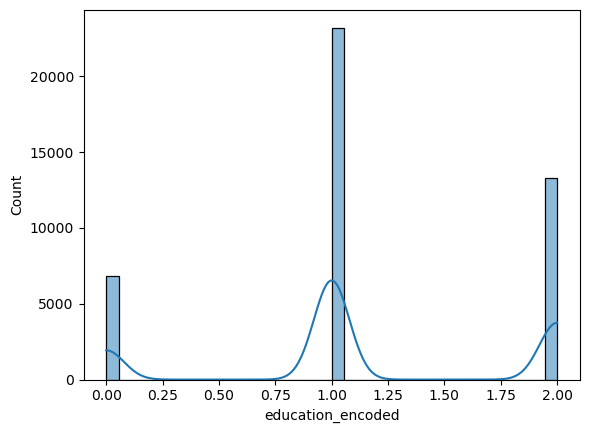

In [358]:
educ_distrib = sns.histplot(data = features,x="education_encoded",kde=True)
plt.show()

In [359]:
features.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,education_encoded
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,not_contacted_before,2.0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,not_contacted_before,1.0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,not_contacted_before,1.0
3,47,blue-collar,married,NaN,no,1506,yes,no,unknown,5,may,92,1,-1,0,not_contacted_before,NaN
4,33,blue-collar,single,NaN,no,1,no,no,unknown,5,may,198,1,-1,0,not_contacted_before,NaN


 Usando o map para substituir default,housing, e loan por 0 e 1

In [360]:
educ = features.drop(columns='education')

# Substituir 'default', 'housing' e 'loan' por 0/1 no DataFrame educ
educ['default'] = educ['default'].map({'no': 0, 'yes': 1})
educ['housing'] = educ['housing'].map({'no': 0, 'yes': 1})
educ['loan']    = educ['loan'].map({'no': 0, 'yes': 1})

# One-Hot Encoding da variável job e marital
educ = pd.get_dummies(educ, columns=['marital','job'], drop_first=True)


copy_feature = educ.copy()

In [361]:
features.shape

(45211, 17)

In [362]:
educ = educ[educ['education_encoded'].notna()]

In [363]:
features.drop(columns=['education','education_encoded'],inplace=True)

In [364]:
educ.drop(columns=['contact','month','poutcome'],inplace=True)

Usando RandomForest para base

In [365]:
# Separar X e y
X = educ.drop(columns=['education_encoded'])
y = educ['education_encoded']



# Divisão em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Criar e treinar o modelo Random Forest
rf_model_1 = RandomForestClassifier(
    n_estimators=100,       # número de árvores
    random_state=42,
    max_depth=None,
    n_jobs=-1
)
rf_model_1.fit(X_train, y_train)

# Avaliar no conjunto de teste
y_pred = rf_model_1.predict(X_test)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Matriz de Confusão:
[[ 709 1178  168]
 [ 581 5687  693]
 [  82 1182 2727]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.52      0.35      0.41      2055
         1.0       0.71      0.82      0.76      6961
         2.0       0.76      0.68      0.72      3991

    accuracy                           0.70     13007
   macro avg       0.66      0.62      0.63     13007
weighted avg       0.69      0.70      0.69     13007



## Análise exploratória da importância das variáveis no Random Forest base

A importância das variáveis foi analisada de forma exploratória a partir do modelo Random Forest base. Essa etapa ajuda a entender quais atributos contribuíram mais para a previsão da variável `education_encoded`, mas não representa a escolha final do modelo de imputação.

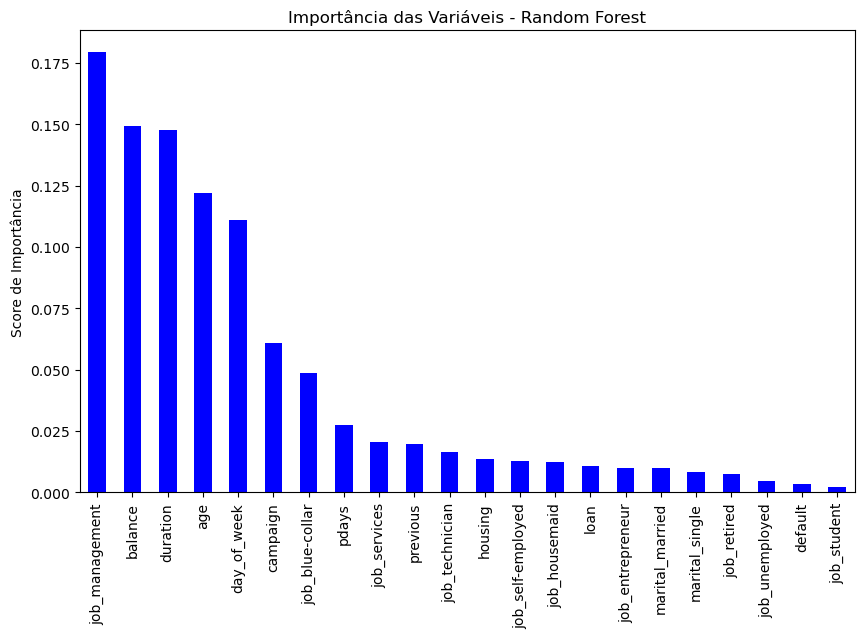

In [366]:


importances = pd.Series(rf_model_1.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='bar', color='blue')
plt.title('Importância das Variáveis - Random Forest')
plt.ylabel('Score de Importância')
plt.show()


# Random Forest com class_weight='balanced'

In [367]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf_model_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)
rf_model_balanced.fit(X_train, y_train)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf_balanced))
print(classification_report(y_test, y_pred_rf_balanced))

[[ 649 1249  157]
 [ 537 5772  652]
 [  73 1213 2705]]
              precision    recall  f1-score   support

         0.0       0.52      0.32      0.39      2055
         1.0       0.70      0.83      0.76      6961
         2.0       0.77      0.68      0.72      3991

    accuracy                           0.70     13007
   macro avg       0.66      0.61      0.62     13007
weighted avg       0.69      0.70      0.69     13007



Como a variável education apresenta desbalanceamento entre as classes, foram testadas estratégias de ponderação de classes, como Random Forest com class_weight='balanced' e XGBoost com sample_weight. A escolha final considerou principalmente o f1-score macro e o recall das classes minoritárias.

In [368]:
copy_feature = copy_feature.drop(columns=['contact', 'month', 'poutcome'])

In [369]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# Garantir que y seja inteiro
y = y.astype(int)

# Divisão treino/teste para avaliação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Pesos balanceados para avaliação
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Modelo para avaliação
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

# Avaliação
y_pred = xgb_model.predict(X_test)

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.43      0.69      0.53      2055
           1       0.77      0.62      0.69      6961
           2       0.72      0.74      0.73      3991

    accuracy                           0.67     13007
   macro avg       0.64      0.68      0.65     13007
weighted avg       0.70      0.67      0.68     13007

Matriz de Confusão:
[[1418  440  197]
 [1674 4335  952]
 [ 202  837 2952]]


In [370]:
# Treinar modelo final com todos os dados conhecidos
sample_weights_final = compute_sample_weight(
    class_weight="balanced",
    y=y
)

xgb_model_final = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model_final.fit(
    X,
    y,
    sample_weight=sample_weights_final
)

# Máscara dos valores ausentes
missing_mask = copy_feature["education_encoded"].isna()

# Separar dados ausentes
X_missing = copy_feature.loc[missing_mask].drop(columns=["education_encoded"])

# Garantir mesmas colunas e mesma ordem do treino
X_missing = X_missing.reindex(columns=X.columns, fill_value=0)

# Imputar valores ausentes
copy_feature.loc[missing_mask, "education_encoded"] = xgb_model_final.predict(X_missing)

Após comparar os modelos, o XGBoost com ponderação por amostra foi escolhido para imputar a variável education. Embora tenha apresentado acurácia menor que a versão sem ponderação, o modelo demonstrou melhor equilíbrio entre as classes, principalmente na classe primary, que anteriormente era pouco reconhecida. Como o objetivo da etapa era imputar valores ausentes de forma menos enviesada pela classe majoritária, a decisão considerou principalmente o f1-score macro e o recall das classes minoritárias, e não apenas a acurácia.

In [371]:
copy_feature.describe()

,age,default,balance,housing,loan,day_of_week,duration,campaign,pdays,previous,education_encoded
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,0.018027,1362.272058,0.555838,0.160226,15.806419,258.163080,2.763841,40.197828,0.580323,1.136184
std,10.618762,0.133049,3044.765829,0.496878,0.366820,8.322476,257.527812,3.098021,100.128746,2.303441,0.672500
min,18.000000,0.000000,-8019.000000,0.000000,0.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,0.000000,72.000000,0.000000,0.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,1.000000
50%,39.000000,0.000000,448.000000,1.000000,0.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,1.000000
75%,48.000000,0.000000,1428.000000,1.000000,0.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,2.000000
max,95.000000,1.000000,102127.000000,1.000000,1.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,2.000000


In [372]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Separando as variaveis  alvo e preditora
y = target['y'].map({'yes':1, 'no':0})
X = copy_feature

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Treino/teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Modelo
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Coeficientes
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": log_reg.coef_[0],
    "odds_ratio": np.exp(log_reg.coef_[0])  # interpretação em termos de chance relativa
}).sort_values(by="odds_ratio", ascending=False)

print(coef_df)

              feature      coef  odds_ratio
6            duration  1.025035    2.787192
8               pdays  0.294673    1.342687
10  education_encoded  0.185837    1.204225
9            previous  0.146240    1.157474
20        job_student  0.097785    1.102725
12     marital_single  0.093337    1.097832
17        job_retired  0.087063    1.090965
2             balance  0.070948    1.073526
0                 age  0.030619    1.031092
22     job_unemployed -0.020457    0.979751
5         day_of_week -0.022980    0.977282
1             default -0.052109    0.949225
11    marital_married -0.057882    0.943762
16     job_management -0.062241    0.939657
18  job_self-employed -0.082194    0.921093
14   job_entrepreneur -0.093367    0.910859
19       job_services -0.095125    0.909260
21     job_technician -0.104739    0.900560
15      job_housemaid -0.108109    0.897529
13    job_blue-collar -0.197070    0.821134
4                loan -0.227002    0.796919
7            campaign -0.374969 

✅ Principais fatores identificados:

Embora duration seja uma variável muito relevante para explicar a aceitação da campanha, ela só é conhecida após o contato com o cliente. Por isso, deve ser interpretada como uma variável de análise posterior da campanha, e não como uma informação disponível antes da abordagem comercial.

Duração da ligação (duration) → é o fator mais forte: quanto mais tempo o cliente permanece na conversa, maior a chance de aceitar.

Situação financeira (housing, loan, balance) → Ter financiamento habitacional ou empréstimo ativo reduz significativamente a probabilidade de aceite.

Maior saldo bancário aumenta levemente a chance.

Histórico de contato (pdays, previous) → clientes que já foram contatados recentemente ou tiveram interações anteriores têm maior probabilidade de aceitar.

Perfil sociodemográfico (education_encoded, categorias de job) →

Maior escolaridade aumenta a chance.

Algumas ocupações (como estudante ou aposentado) aumentam a probabilidade, enquanto outras (blue-collar, housemaid, entrepreneur) reduzem.

Intensidade da campanha (campaign) → muitas tentativas de contato reduzem a chance de aceite (fadiga do cliente).

📊 Conclusão de negócio
O modelo mostra que a decisão do cliente depende de uma combinação de qualidade do contato (tempo de ligação), condições financeiras (empréstimos e financiamentos), histórico de relacionamento (pdays, previous) e perfil sociodemográfico.
Ou seja, para aumentar a taxa de sucesso da campanha, o banco deve:

-> Melhorar a qualidade da abordagem comercial durante o contato, pois ligações mais longas parecem estar associadas a maior interesse do cliente.

-> Evitar insistência excessiva com muitas tentativas de contato.

-> Segmentar clientes com maior saldo e perfis mais receptivos.

-> Reduzir esforços em clientes com maior comprometimento financeiro, como empréstimos e financiamento habitacional.